# DeepLOB Probability-Based Portfolio Backtest

This notebook runs a single-asset portfolio backtest using a trained DeepLOB model. The model probabilities are converted into a continuous target position, with an initial portfolio notional capital of 1,000,000.

The execution prices are always the raw tradable `BidPrice1` and `AskPrice1`. The smoothed data is only used indirectly through the trained labels/model; it is not used as an executable price.

## 1. Configuration

Set the checkpoint, parquet file, test segment, and portfolio sizing parameters here. By default, the notebook uses the final 15% of the dataset, matching the training notebooks' held-out test split.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
CHECKPOINT_PATH = PROJECT_ROOT / "Output_models" / "deeplob5_stabilized_best.pth"
DATA_PATH = PROJECT_ROOT / "test_Xy.parquet"

TRAIN_FRAC = 0.70
TEST_FRAC = 0.15
BATCH_SIZE = 1024
SEQ_LEN_FALLBACK = 100

# Portfolio sizing parameters.
INITIAL_CAPITAL = 1_000_000.0
MAX_NOTIONAL_FRACTION = 0.10
EDGE_ENTRY_THRESHOLD = 0.40
EDGE_FULL_POSITION = 0.60
EDGE_SMOOTH_WINDOW = 20
REBALANCE_INTERVAL_TICKS = 20
TARGET_CHANGE_EPS = 1e-4

# Execution realism parameters. The spread is already paid through Bid/Ask execution.
EXECUTION_LAG_TICKS = 1
FEE_BPS_PER_SIDE = 0.0
SLIPPAGE_BPS_PER_SIDE = 0.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Data parquet not found: {DATA_PATH}")

Using device: cpu


## 2. Model Definition

The model architecture is embedded directly so this notebook does not depend on any local helper package. Metadata such as feature columns, sequence length, and hidden size is loaded from the checkpoint when available.

In [2]:
DEFAULT_FEATURE_COLS = [
    "BidPrice5", "BidVolume5", "BidPrice4", "BidVolume4", "BidPrice3", "BidVolume3",
    "BidPrice2", "BidVolume2", "BidPrice1", "BidVolume1",
    "AskPrice5", "AskVolume5", "AskPrice4", "AskVolume4", "AskPrice3", "AskVolume3",
    "AskPrice2", "AskVolume2", "AskPrice1", "AskVolume1",
]

LABEL_MAP = {-1.0: 0, 0.0: 1, 1.0: 2}
INV_LABEL = {0: -1.0, 1: 0.0, 2: 1.0}


class DeepLOB5Stable(nn.Module):
    def __init__(self, num_classes: int = 3, hidden_size: int = 64):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 2), padding=(0, 1)),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(16, 16, kernel_size=(3, 1), padding=(1, 0)),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(16, 32, kernel_size=(1, 2), padding=(0, 0)),
            nn.LeakyReLU(0.01, inplace=True),
        )
        self.branch1 = nn.Sequential(nn.Conv2d(32, 32, kernel_size=(1, 1)), nn.LeakyReLU(0.01, inplace=True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 1)), nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(32, 32, kernel_size=(3, 1), padding=(1, 0)), nn.LeakyReLU(0.01, inplace=True),
        )
        self.branch5 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 1)), nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(32, 32, kernel_size=(5, 1), padding=(2, 0)), nn.LeakyReLU(0.01, inplace=True),
        )
        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=(3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(32, 32, kernel_size=(1, 1)), nn.LeakyReLU(0.01, inplace=True),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(1)
        x = self.conv_block(x)
        x = torch.cat([self.branch1(x), self.branch3(x), self.branch5(x), self.branch_pool(x)], dim=1)
        x = x.mean(dim=3)
        x = x.transpose(1, 2)
        x, _ = self.lstm(x)
        x = self.dropout(x[:, -1, :])
        return self.fc(x)

In [3]:
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
feature_cols = ckpt.get("feature_cols") or DEFAULT_FEATURE_COLS
seq_len = int(ckpt.get("seq_len", SEQ_LEN_FALLBACK))
num_classes = int(ckpt.get("num_classes", 3))
hidden_size = int(ckpt.get("hidden_size", 64))

model = DeepLOB5Stable(num_classes=num_classes, hidden_size=hidden_size).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Checkpoint:", CHECKPOINT_PATH)
print("best_epoch:", ckpt.get("best_epoch"))
print("best_val_f1:", ckpt.get("best_val_f1"))
print("seq_len:", seq_len)
print("n_features:", len(feature_cols))

Checkpoint: /Users/edwardzhang/Downloads/DeepLOB-main/Output_models/deeplob5_stabilized_best.pth
best_epoch: 42
best_val_f1: 0.5852603995943448
seq_len: 100
n_features: 20


## 3. Load and Normalize the Test Segment

The model input features are raw LOB columns. The training split mean and standard deviation are used to normalize the test segment, matching the original training and inference scripts.

In [4]:
load_cols = ["index"] + list(feature_cols) + ["label"]
df = pd.read_parquet(DATA_PATH, columns=load_cols)
df = df.sort_values("index").reset_index(drop=True)
df["label_cls"] = df["label"].map(LABEL_MAP).astype(np.int64)

n = len(df)
train_end = int(n * TRAIN_FRAC)
test_start = int(n * (1.0 - TEST_FRAC))

train_df = df.iloc[:train_end]
test_df = df.iloc[test_start:]

X_train_raw = train_df[feature_cols].to_numpy(dtype=np.float32)
X_test_raw = test_df[feature_cols].to_numpy(dtype=np.float32)
y_test = test_df["label_cls"].to_numpy(dtype=np.int64)

train_mean = X_train_raw.mean(axis=0)
train_std = X_train_raw.std(axis=0)
train_std = np.where(train_std < 1e-8, 1.0, train_std)
X_test = (X_test_raw - train_mean) / train_std

print("full rows:", n)
print("normalization train rows:", len(train_df))
print(f"test rows: iloc [{test_start}, {n}) = {len(test_df):,}")
display(test_df["label"].value_counts().sort_index().rename("count"))

full rows: 8770846
normalization train rows: 6139592
test rows: iloc [7455219, 8770846) = 1,315,627


label
-1.0    170911
 0.0    975101
 1.0    169615
Name: count, dtype: int64

## 4. Generate Model Probabilities

Each prediction is attached to the end of its rolling input window. This `signal_iloc` is the signal timestamp. The backtest executes at `signal_iloc + EXECUTION_LAG_TICKS`.

In [5]:
class LOBSequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int):
        assert len(X) == len(y)
        assert len(X) >= seq_len
        self.X = X
        self.y = y
        self.seq_len = seq_len

    def __len__(self) -> int:
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, idx: int):
        x = self.X[idx : idx + self.seq_len]
        y = self.y[idx + self.seq_len - 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


@torch.no_grad()
def collect_logits(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    logits_all = []
    y_all = []
    for batch_idx, (xb, yb) in enumerate(loader):
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        logits_all.append(logits.cpu().numpy())
        y_all.append(yb.numpy())
        if (batch_idx + 1) % 25 == 0 or (batch_idx + 1) == len(loader):
            print(f"batch {batch_idx + 1}/{len(loader)}")
    return np.concatenate(logits_all), np.concatenate(y_all)


def window_end_ilocs(test_start: int, n_total: int, seq_len: int) -> np.ndarray:
    n_test = n_total - test_start
    return test_start + np.arange(seq_len - 1, n_test, dtype=np.int64)

In [6]:
test_ds = LOBSequenceDataset(X_test, y_test, seq_len)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("prediction windows:", len(test_ds))
logits, y_true = collect_logits(model, test_loader, device)
probs = torch.softmax(torch.from_numpy(logits.astype(np.float32)), dim=1).numpy()
raw_cls = np.argmax(logits, axis=1).astype(np.int64)
signal_iloc = window_end_ilocs(test_start, n, seq_len)

pred_df = pd.DataFrame({
    "signal_iloc": signal_iloc,
    "data_index": df["index"].to_numpy()[signal_iloc],
    "y_true_cls": y_true.astype(np.int64),
    "raw_pred_cls": raw_cls,
    "y_true_label": [INV_LABEL[int(x)] for x in y_true],
    "raw_pred_label": [INV_LABEL[int(x)] for x in raw_cls],
    "prob_down": probs[:, 0],
    "prob_stationary": probs[:, 1],
    "prob_up": probs[:, 2],
})

display(pred_df.head())
display(pred_df["raw_pred_label"].value_counts().sort_index())

prediction windows: 1315528
batch 25/1285
batch 50/1285
batch 75/1285
batch 100/1285
batch 125/1285
batch 150/1285
batch 175/1285
batch 200/1285
batch 225/1285
batch 250/1285
batch 275/1285
batch 300/1285
batch 325/1285
batch 350/1285
batch 375/1285
batch 400/1285
batch 425/1285
batch 450/1285
batch 475/1285
batch 500/1285
batch 525/1285
batch 550/1285
batch 575/1285
batch 600/1285
batch 625/1285
batch 650/1285
batch 675/1285
batch 700/1285
batch 725/1285
batch 750/1285
batch 775/1285
batch 800/1285
batch 825/1285
batch 850/1285
batch 875/1285
batch 900/1285
batch 925/1285
batch 950/1285
batch 975/1285
batch 1000/1285
batch 1025/1285
batch 1050/1285
batch 1075/1285
batch 1100/1285
batch 1125/1285
batch 1150/1285
batch 1175/1285
batch 1200/1285
batch 1225/1285
batch 1250/1285
batch 1275/1285
batch 1285/1285


,signal_iloc,data_index,y_true_cls,raw_pred_cls,y_true_label,raw_pred_label,prob_down,prob_stationary,prob_up
0,7455318,7455318,2,2,1.0,1.0,0.029105,0.382502,0.588393
1,7455319,7455319,2,2,1.0,1.0,0.008047,0.181349,0.810605
2,7455320,7455320,2,2,1.0,1.0,0.009063,0.200594,0.790344
3,7455321,7455321,2,2,1.0,1.0,0.028188,0.350448,0.621364
4,7455322,7455322,2,1,1.0,0.0,0.078841,0.504865,0.416293


raw_pred_label
-1.0    223615
 0.0    860373
 1.0    231540
Name: count, dtype: int64

## 5. Convert Probabilities Into Smoothed Target Notional

This version uses a horizon-aware version of strategy C. The base model was trained with a k=20 smoothed label, so the portfolio layer also works on a similar horizon:

- Compute `edge_raw = P(up) - P(down)`.
- Apply a trailing rolling mean over `EDGE_SMOOTH_WINDOW = 20` predictions. This uses only current and past probabilities, so it does not introduce lookahead bias.
- Create a target only every `REBALANCE_INTERVAL_TICKS = 20` ticks. This keeps the trading frequency closer to the label horizon and avoids checking every tick.
- Execute each target at `signal_iloc + EXECUTION_LAG_TICKS`, so the signal timestamp and execution timestamp remain separated.

If the absolute smoothed edge is below `EDGE_ENTRY_THRESHOLD`, the target position is flat. Otherwise, target notional scales linearly with edge strength and is capped at `MAX_NOTIONAL_FRACTION * NAV`.

In [7]:
def build_probability_targets(pred: pd.DataFrame) -> pd.DataFrame:
    out = pred.copy()
    out["edge_raw"] = out["prob_up"].to_numpy() - out["prob_down"].to_numpy()

    # Trailing smoothing only: edge_smooth[t] uses edge_raw[:t], never future probabilities.
    out["edge_smooth"] = (
        out["edge_raw"]
        .rolling(window=EDGE_SMOOTH_WINDOW, min_periods=1)
        .mean()
    )

    edge = out["edge_smooth"].to_numpy(dtype=np.float64)
    target_frac = np.zeros(len(out), dtype=np.float64)
    active = np.abs(edge) >= EDGE_ENTRY_THRESHOLD
    target_frac[active] = np.sign(edge[active]) * np.minimum(np.abs(edge[active]) / EDGE_FULL_POSITION, 1.0)

    out["target_frac"] = target_frac
    out["target_iloc"] = out["signal_iloc"].astype(np.int64) + int(EXECUTION_LAG_TICKS)

    first_signal = int(out["signal_iloc"].iloc[0])
    rebalance_mask = ((out["signal_iloc"].astype(np.int64) - first_signal) % REBALANCE_INTERVAL_TICKS) == 0
    out = out[rebalance_mask & (out["target_iloc"] < n)].reset_index(drop=True)
    return out


target_df = build_probability_targets(pred_df)
display(target_df[["signal_iloc", "target_iloc", "prob_down", "prob_up", "edge_raw", "edge_smooth", "target_frac"]].head(10))
display(target_df["target_frac"].describe())
print("rebalance rows:", len(target_df))
print("active rebalance rows:", int((target_df["target_frac"] != 0).sum()), "/", len(target_df))


,signal_iloc,target_iloc,prob_down,prob_up,edge_raw,edge_smooth,target_frac
0,7455318,7455319,0.029105,0.588393,0.559288,0.559288,0.932147
1,7455338,7455339,0.022964,0.644505,0.621541,0.408080,0.680134
2,7455358,7455359,0.289296,0.079873,-0.209423,-0.217038,0.000000
3,7455378,7455379,0.048590,0.384216,0.335626,0.139029,0.000000
4,7455398,7455399,0.651693,0.014876,-0.636817,-0.221046,0.000000
5,7455418,7455419,0.137742,0.171145,0.033403,-0.375870,0.000000
6,7455438,7455439,0.036813,0.407993,0.371180,0.100276,0.000000
7,7455458,7455459,0.437129,0.031651,-0.405478,0.045283,0.000000
8,7455478,7455479,0.023407,0.555164,0.531757,0.240460,0.000000
9,7455498,7455499,0.487247,0.032806,-0.454441,-0.211065,0.000000


count    65777.000000
mean         0.008321
std          0.406807
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: target_frac, dtype: float64

rebalance rows: 65777
active rebalance rows: 14462 / 65777


## 6. Event-Driven Portfolio Execution Engine

The engine is event-driven: it only processes scheduled rebalance timestamps plus the final liquidation timestamp. It does not scan every tick for a trading decision.

Execution still uses raw `BidPrice1` / `AskPrice1`:

- Increasing a long position or covering a short crosses the ask.
- Reducing a long position or increasing a short crosses the bid.
- The Bid/Ask spread is therefore included directly in the execution price.

The NAV curve produced here is sampled at rebalance events, not every tick. This is intentional for speed and to keep the portfolio horizon aligned with k=20.

In [8]:
price_df = pd.read_parquet(DATA_PATH, columns=["index", "BidPrice1", "AskPrice1"])
price_df = price_df.sort_values("index").reset_index(drop=True)


def execution_price_for_delta(delta_qty: float, bid: float, ask: float) -> float:
    return float(ask if delta_qty > 0 else bid)


def run_probability_portfolio_backtest(price_df: pd.DataFrame, targets_df: pd.DataFrame):
    bid = price_df["BidPrice1"].to_numpy(dtype=np.float64)
    ask = price_df["AskPrice1"].to_numpy(dtype=np.float64)
    n_local = len(price_df)

    cash = float(INITIAL_CAPITAL)
    qty = 0.0
    avg_entry = np.nan
    trade_rows = []
    curve_rows = []

    for row in targets_df.itertuples(index=False):
        iloc = int(row.target_iloc)
        target_frac = float(row.target_frac)
        if iloc < 0 or iloc >= n_local:
            continue
        b, a = float(bid[iloc]), float(ask[iloc])
        if not np.isfinite(b) or not np.isfinite(a):
            continue

        mid = (b + a) / 2.0
        nav_before = cash + qty * mid
        target_notional = nav_before * MAX_NOTIONAL_FRACTION * target_frac
        target_qty = target_notional / mid if mid > 0 else 0.0
        delta_qty = target_qty - qty

        if abs(delta_qty) > TARGET_CHANGE_EPS:
            px = execution_price_for_delta(delta_qty, b, a)
            trade_notional = abs(delta_qty) * px
            cost = trade_notional * (FEE_BPS_PER_SIDE + SLIPPAGE_BPS_PER_SIDE) / 10000.0
            cash -= delta_qty * px
            cash -= cost

            new_qty = qty + delta_qty
            if abs(new_qty) < TARGET_CHANGE_EPS:
                avg_entry = np.nan
                new_qty = 0.0
            elif qty == 0 or np.sign(new_qty) != np.sign(qty):
                avg_entry = px
            elif np.sign(delta_qty) == np.sign(qty):
                avg_entry = (abs(qty) * avg_entry + abs(delta_qty) * px) / abs(new_qty)

            trade_rows.append({
                "iloc": iloc,
                "signal_iloc": int(row.signal_iloc),
                "target_frac": target_frac,
                "edge_raw": float(row.edge_raw),
                "edge_smooth": float(row.edge_smooth),
                "price": px,
                "delta_qty": delta_qty,
                "qty_after": new_qty,
                "trade_notional": trade_notional,
                "cost": cost,
            })
            qty = new_qty

        nav = cash + qty * mid
        curve_rows.append({
            "iloc": iloc,
            "signal_iloc": int(row.signal_iloc),
            "cash": cash,
            "qty": qty,
            "mid": mid,
            "nav": nav,
            "pnl": nav - INITIAL_CAPITAL,
            "return": nav / INITIAL_CAPITAL - 1.0,
            "gross_notional": abs(qty) * mid,
            "leverage": abs(qty) * mid / nav if nav != 0 else np.nan,
            "target_frac": target_frac,
            "edge_smooth": float(row.edge_smooth),
        })

    # Liquidate at final tick using an executable price.
    if qty != 0:
        iloc = n_local - 1
        b, a = float(bid[iloc]), float(ask[iloc])
        if np.isfinite(b) and np.isfinite(a):
            delta_qty = -qty
            px = execution_price_for_delta(delta_qty, b, a)
            trade_notional = abs(delta_qty) * px
            cost = trade_notional * (FEE_BPS_PER_SIDE + SLIPPAGE_BPS_PER_SIDE) / 10000.0
            cash -= delta_qty * px
            cash -= cost
            trade_rows.append({
                "iloc": iloc,
                "signal_iloc": np.nan,
                "target_frac": 0.0,
                "edge_raw": np.nan,
                "edge_smooth": np.nan,
                "price": px,
                "delta_qty": delta_qty,
                "qty_after": 0.0,
                "trade_notional": trade_notional,
                "cost": cost,
            })
            mid = (b + a) / 2.0
            qty = 0.0
            curve_rows.append({
                "iloc": iloc,
                "signal_iloc": np.nan,
                "cash": cash,
                "qty": 0.0,
                "mid": mid,
                "nav": cash,
                "pnl": cash - INITIAL_CAPITAL,
                "return": cash / INITIAL_CAPITAL - 1.0,
                "gross_notional": 0.0,
                "leverage": 0.0,
                "target_frac": 0.0,
                "edge_smooth": np.nan,
            })

    return pd.DataFrame(curve_rows), pd.DataFrame(trade_rows)


## 7. Run the Portfolio Backtest

This run uses the smoothed k=20-aligned target schedule. The number of rebalance events should be much smaller than the number of raw prediction windows. The final position is liquidated at the last row using executable Bid/Ask prices.

In [9]:
portfolio_curve_df, portfolio_trades_df = run_probability_portfolio_backtest(price_df, target_df)


def summarize_portfolio(curve: pd.DataFrame, trades: pd.DataFrame) -> pd.Series:
    nav = curve["nav"].to_numpy(dtype=np.float64)
    returns = pd.Series(nav).pct_change().replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    peak = np.maximum.accumulate(nav)
    drawdown = nav / peak - 1.0
    sharpe_like = 0.0
    if len(returns) > 1 and np.std(returns) > 1e-12:
        sharpe_like = float(np.mean(returns) / np.std(returns) * np.sqrt(len(returns)))
    return pd.Series({
        "initial_capital": INITIAL_CAPITAL,
        "final_nav": float(nav[-1]),
        "total_pnl": float(nav[-1] - INITIAL_CAPITAL),
        "total_return": float(nav[-1] / INITIAL_CAPITAL - 1.0),
        "max_drawdown_pct": float(np.min(drawdown)),
        "sharpe_like": sharpe_like,
        "n_rebalance_events": int(len(curve)),
        "n_trade_executions": int(len(trades)),
        "total_turnover": float(trades["trade_notional"].sum()) if not trades.empty else 0.0,
        "total_cost": float(trades["cost"].sum()) if not trades.empty else 0.0,
        "avg_abs_leverage": float(curve["leverage"].abs().mean()),
        "max_abs_leverage": float(curve["leverage"].abs().max()),
    })


portfolio_summary = summarize_portfolio(portfolio_curve_df, portfolio_trades_df)
display(portfolio_summary.to_frame("value"))
display(portfolio_trades_df.head())
display(portfolio_curve_df.tail())

,value
initial_capital,1.000000e+06
final_nav,8.857680e+05
total_pnl,-1.142320e+05
total_return,-1.142320e-01
max_drawdown_pct,-1.143063e-01
sharpe_like,-3.350691e+01
n_rebalance_events,6.577800e+04
n_trade_executions,2.527900e+04
total_turnover,1.962432e+09
total_cost,0.000000e+00


,iloc,signal_iloc,target_frac,edge_raw,edge_smooth,price,delta_qty,qty_after,trade_notional,cost
0,7455319,7455318.0,0.932147,0.559288,0.559288,169660.0,0.549453,0.549453,93220.165345,0.0
1,7455339,7455338.0,0.680134,0.621541,0.408080,169680.0,-0.148637,0.400816,25220.682721,0.0
2,7455359,7455358.0,0.000000,-0.209423,-0.217038,169620.0,-0.400816,0.000000,67986.422716,0.0
3,7455639,7455638.0,0.742431,-0.217482,0.445458,169750.0,0.437400,0.437400,74248.650402,0.0
4,7455659,7455658.0,0.000000,0.110547,-0.275467,169740.0,-0.437400,0.000000,74244.276402,0.0


,iloc,signal_iloc,cash,qty,mid,nav,pnl,return,gross_notional,leverage,target_frac,edge_smooth
65773,8770779,8770778.0,966995.707784,-0.534604,151920.0,885778.675279,-114221.324721,-0.114221,81217.032505,0.091690,-0.916894,-0.550137
65774,8770799,8770798.0,885767.983200,0.000000,151935.0,885767.983200,-114232.016800,-0.114232,0.000000,0.000000,0.000000,-0.105509
65775,8770819,8770818.0,885767.983200,0.000000,151910.0,885767.983200,-114232.016800,-0.114232,0.000000,0.000000,0.000000,-0.236356
65776,8770839,8770838.0,952099.845692,-0.436767,151890.0,885759.247853,-114240.752147,-0.114241,66340.597839,0.074897,-0.748961,-0.449377
65777,8770845,NaN,885767.983200,0.000000,151860.0,885767.983200,-114232.016800,-0.114232,0.000000,0.000000,0.000000,NaN


## 8. Plots

The NAV curve is sampled at rebalance events. The exposure plot shows gross notional after each scheduled rebalance.

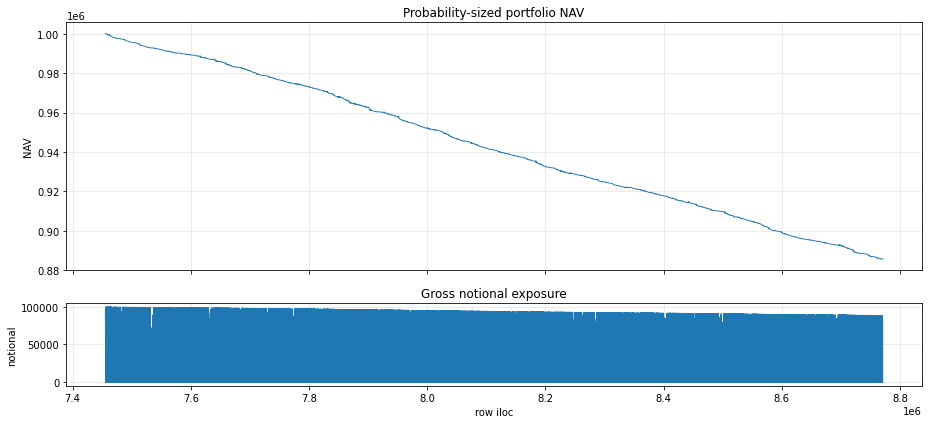

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
x = portfolio_curve_df["iloc"].to_numpy()
axes[0].plot(x, portfolio_curve_df["nav"].to_numpy(), linewidth=0.9)
axes[0].set_title("Probability-sized portfolio NAV")
axes[0].set_ylabel("NAV")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, portfolio_curve_df["gross_notional"].to_numpy(), linewidth=0.8)
axes[1].set_title("Gross notional exposure")
axes[1].set_xlabel("row iloc")
axes[1].set_ylabel("notional")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Optional Exports

Set `EXPORT_OUTPUTS = True` if you want to save the generated probabilities, target positions, portfolio curve, trades, and summary.

In [11]:
EXPORT_OUTPUTS = False
OUT_DIR = PROJECT_ROOT / "probability_portfolio_outputs"

if EXPORT_OUTPUTS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    pred_df.to_parquet(OUT_DIR / "model_probabilities.parquet", index=False)
    target_df.to_parquet(OUT_DIR / "target_positions.parquet", index=False)
    portfolio_curve_df.to_csv(OUT_DIR / "portfolio_curve.csv", index=False)
    portfolio_trades_df.to_csv(OUT_DIR / "portfolio_trades.csv", index=False)
    portfolio_summary.to_frame("value").to_csv(OUT_DIR / "portfolio_summary.csv")
    print("Saved outputs to", OUT_DIR.resolve())